# 03 — Balanced 2M Subset for UMAG Training





## 1. Imports, Paths & Configuration


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 1 — Imports, DuckDB connection, raw view
# Self-contained: run this cell first after any kernel restart.
# ══════════════════════════════════════════════════════════════════════════════

import math, time, shutil, subprocess, json
from datetime import datetime
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Add project root to path so src/ is importable
sys.path.insert(0, str(Path('..').resolve()))
from src.utils.paths import P

sns.set_theme(style='whitegrid', font_scale=1.05)
PAL = sns.color_palette('tab10')

# ── Paths ──────────────────────────────────────────────────────────────────────
MERREC  = Path('/Volumes/T5 EVO/hf/merrec')
OUT_DIR = Path('/Volumes/T5 EVO/hf/merrec_balanced_2M')
OUT_DIR.mkdir(parents=True, exist_ok=True)
Path('/Volumes/T5 EVO/tmp').mkdir(parents=True, exist_ok=True)

assert MERREC.exists(), f'Raw data not found: {MERREC} — check drive mount'

# ── Prevent macOS USB suspend during long scans ────────────────────────────────
subprocess.Popen(['caffeinate', '-dims'])
print('caffeinate active — drive will not suspend ✓')

# ── DuckDB connection ──────────────────────────────────────────────────────────
con = duckdb.connect()
con.execute("SET memory_limit='6GB'")
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute("SET temp_directory='/Volumes/T5 EVO/tmp'")
con.execute("SET max_temp_directory_size='50GB'")

# ── Build raw view from explicit file list ─────────────────────────────────────
# Never use glob after a remount — DuckDB captures stale OS directory cache.
# Explicit list forces re-enumeration from the live filesystem.
all_parquet = sorted(MERREC.glob('*/*.parquet'))
assert len(all_parquet) == 2170, \
    f'Expected 2170 parquet files, found {len(all_parquet)} — check drive mount'

file_list = '[' + ', '.join(f"'{p}'" for p in all_parquet) + ']'
con.execute(f"CREATE OR REPLACE VIEW raw AS SELECT * FROM read_parquet({file_list})")

from collections import Counter
partition_dist = Counter(f.parent.name for f in all_parquet)
print(f'raw view: {len(all_parquet)} files across {len(partition_dist)} partitions ✓')
for part, count in sorted(partition_dist.items()):
    print(f'  {part}: {count} files')

caffeinate active — drive will not suspend ✓
raw view: 2170 files across 6 partitions ✓
  20230501: 312 files
  20230601: 324 files
  20230701: 359 files
  20230801: 386 files
  20230901: 380 files
  20231001: 409 files


In [2]:
# ── DuckDB: lazy Parquet view, everything streams — no full RAM load ───────────
con = duckdb.connect(':memory:')
con.execute(f"PRAGMA threads={CFG['DB_THREADS']}")
con.execute(f"PRAGMA memory_limit='{CFG['DB_MEMORY']}'")
con.execute(f"SET temp_directory='{TMP_DIR}'")
con.execute(f"PRAGMA max_temp_directory_size='{CFG['DB_TMP_MAX']}'")
con.execute('SET preserve_insertion_order=false')   # ~30% faster aggregations

con.execute(f"""
CREATE VIEW raw AS
SELECT * FROM read_parquet('{RAW_PATH}/**/*.parquet')
""")

PARTITIONS = sorted([p.name for p in RAW_PATH.iterdir() if p.is_dir()])
print(f'DuckDB ready.  Partitions discovered: {PARTITIONS}')

DuckDB ready.  Partitions discovered: ['.cache', '20230501', '20230601', '20230701', '20230801', '20230901', '20231001']



## 2. Pre-Flight: Confirm Raw Imbalance (one scan)



Pre-flight scan (streaming — counts event types + monthly volume)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Scan completed in 42.6s
  Total events confirmed: 1,268,092,738  (EDA: 1,268,092,738)
  Event types found: 6  (EDA: 6)

Event availability vs target:
Event                               Raw count   Raw %     Target   Feasible
---------------------------------------------------------------------------
item_view                       1,054,294,103  83.14%     800,000          ✓
item_like                         182,889,825  14.42%     240,000          ✓
item_add_to_cart_tap               19,704,822   1.55%     400,000          ✓
buy_comp                            1,124,263   0.09%     360,000          ✓
__other__ (pooled)                 10,079,725            200,000          ✓

Monthly volume CV: 0.134  (>0.2 = needs temporal equalisation)


,month,cnt
0,2023-05-01,174872167
1,2023-06-01,182678455
2,2023-07-01,208070247
3,2023-08-01,230478916
4,2023-09-01,224110520
5,2023-10-01,247882433


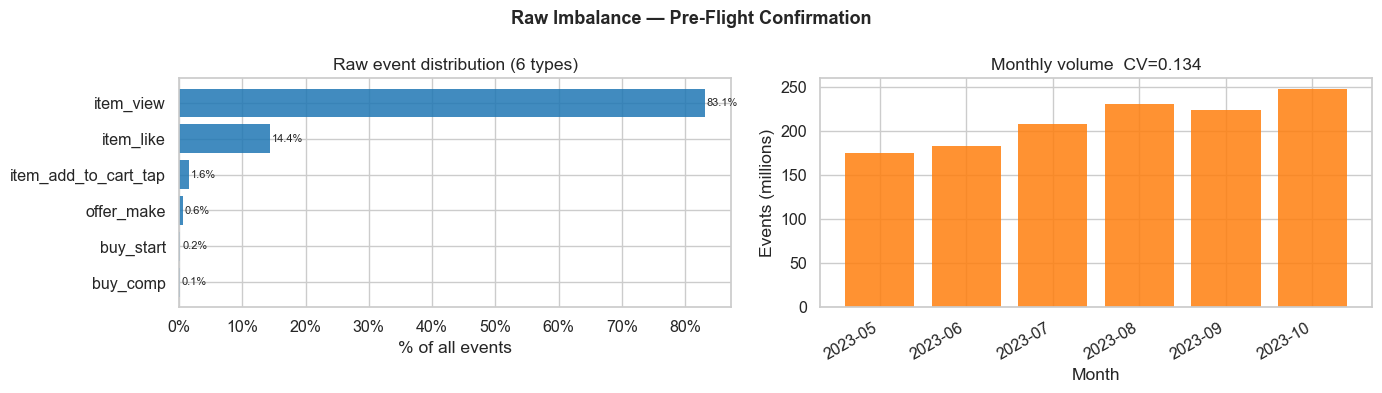

  ✓ saved preflight_raw_imbalance.png


In [4]:
print('Pre-flight scan (streaming — counts event types + monthly volume)...')
t0 = time.time()

# Single pass: event distribution + monthly volume
event_df = con.execute("""
    SELECT event_id,
           COUNT(*) AS cnt,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 3) AS pct
    FROM raw
    GROUP BY event_id
    ORDER BY cnt DESC
""").df()

monthly_df = con.execute("""
    SELECT DATE_TRUNC('month', stime)::DATE AS month,
           COUNT(*) AS cnt
    FROM raw
    GROUP BY month ORDER BY month
""").df()
monthly_df['month'] = pd.to_datetime(monthly_df['month'])

print(f'  Scan completed in {time.time()-t0:.1f}s')
print(f'  Total events confirmed: {event_df["cnt"].sum():,}  (EDA: 1,268,092,738)')
print(f'  Event types found: {len(event_df)}  (EDA: 6)')
print()

# Availability check: will our target rows fit inside actual counts?
avail = dict(zip(event_df['event_id'], event_df['cnt']))
print('Event availability vs target:')
print(f'{"Event":<30} {"Raw count":>14} {"Raw %":>7} {"Target":>10} {"Feasible":>10}')
print('-' * 75)
for ev, w in CFG['EVENT_WEIGHTS'].items():
    if ev == '__other__':
        other_cnt = sum(v for k,v in avail.items() if k not in CFG['EVENT_WEIGHTS'])
        target_n  = int(w * CFG['TARGET_ROWS'])
        feasible  = '✓' if other_cnt >= target_n else f'⚠ only {other_cnt:,}'
        print(f'{"__other__ (pooled)":<30} {other_cnt:>14,} {"":>7} {target_n:>10,} {feasible:>10}')
    else:
        cnt       = avail.get(ev, 0)
        pct       = cnt / event_df['cnt'].sum() * 100
        target_n  = int(w * CFG['TARGET_ROWS'])
        feasible  = '✓' if cnt >= target_n else f'⚠ only {cnt:,}'
        print(f'{ev:<30} {cnt:>14,} {pct:>6.2f}%  {target_n:>10,} {feasible:>10}')

print()
cv_monthly = monthly_df['cnt'].std() / monthly_df['cnt'].mean()
print(f'Monthly volume CV: {cv_monthly:.3f}  (>0.2 = needs temporal equalisation)')
display(monthly_df)

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.barh(event_df['event_id'][::-1], event_df['pct'][::-1],
         color=PAL[0], edgecolor='none', alpha=0.85)
ax1.set(xlabel='% of all events', title=f'Raw event distribution ({len(event_df)} types)')
ax1.xaxis.set_major_formatter(mticker.PercentFormatter())
for i, (ev, p) in enumerate(zip(event_df['event_id'][::-1], event_df['pct'][::-1])):
    ax1.text(p + 0.3, i, f'{p:.1f}%', va='center', fontsize=8)

monthly_df['m'] = monthly_df['month'].dt.strftime('%Y-%m')
ax2.bar(monthly_df['m'], monthly_df['cnt'] / 1e6, color=PAL[1], edgecolor='none', alpha=0.85)
ax2.set(xlabel='Month', ylabel='Events (millions)', title=f'Monthly volume  CV={cv_monthly:.3f}')
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right')

fig.suptitle('Raw Imbalance — Pre-Flight Confirmation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'preflight_raw_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('  ✓ saved preflight_raw_imbalance.png')


## 3. Stage 1 — Event-Type Stratification



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 1 — Event-Type Stratified Sampling (FINAL — MEMORY SAFE)
# Sampling method: WHERE random() < fraction — single-pass, O(1) memory
# Exact count guaranteed by: oversample at 1.2x → sort small result → LIMIT N
# This avoids sorting 1.05B rows; only sorts the ~960K oversampled subset.
# ══════════════════════════════════════════════════════════════════════════════

import math, time, shutil, subprocess
import duckdb
from pathlib import Path

# ── Configuration ──────────────────────────────────────────────────────────────
TARGET   = 2_000_000
SEED     = 42
MERREC   = Path('/Volumes/T5 EVO/hf/merrec')
OUT_DIR  = Path('/Volumes/T5 EVO/hf/merrec_balanced_2M')
S1_DIR   = OUT_DIR / '_s1_parts'
S1_PATH  = OUT_DIR / '_s1_events.parquet'
OUT_DIR.mkdir(parents=True, exist_ok=True)

EVENT_WEIGHTS = {
    'item_view'            : 0.40,
    'item_add_to_cart_tap' : 0.20,
    'buy_comp'             : 0.18,
    'item_like'            : 0.12,
    '__other__'            : 0.10,
}

# Exact counts confirmed from full-corpus COUNT(*) scan
AVAIL_MAP = {
    'item_view'            : 1_054_294_103,
    'item_like'            :   182_889_825,
    'item_add_to_cart_tap' :    19_704_822,
    'offer_make'           :     7_319_254,
    'buy_start'            :     2_760_471,
    'buy_comp'             :     1_124_263,
}

# ── Prevent macOS USB suspend ──────────────────────────────────────────────────
subprocess.Popen(['caffeinate', '-dims'])
print('caffeinate active ✓')

# ── Connect DuckDB ─────────────────────────────────────────────────────────────
con = duckdb.connect()
con.execute("SET memory_limit='6GB'")          # give more headroom
con.execute("SET threads=4")                   # fewer threads = less peak RAM
con.execute("SET preserve_insertion_order=false")  # as DuckDB itself recommends
con.execute("SET temp_directory='/Volumes/T5 EVO/tmp'")
con.execute("SET max_temp_directory_size='50GB'")
Path('/Volumes/T5 EVO/tmp').mkdir(parents=True, exist_ok=True)

# ── Build raw view ─────────────────────────────────────────────────────────────
all_parquet = sorted(MERREC.glob('*/*.parquet'))
assert len(all_parquet) == 2170, \
    f'Expected 2170 files, found {len(all_parquet)} — check mount'
file_list = '[' + ', '.join(f"'{p}'" for p in all_parquet) + ']'
con.execute(f"CREATE OR REPLACE VIEW raw AS SELECT * FROM read_parquet({file_list})")
print(f'raw view: {len(all_parquet)} files ✓')

# ── Allocation math (Hare-Niemeyer) ───────────────────────────────────────────
known_events = set(AVAIL_MAP.keys())
total_avail  = sum(AVAIL_MAP.values())

named_cfg = {k: float(v) for k, v in EVENT_WEIGHTS.items()
             if k != '__other__' and k in known_events}
other_w   = float(EVENT_WEIGHTS.get('__other__', 0.0))
total_w   = sum(named_cfg.values()) + other_w
named_w   = {k: v / total_w for k, v in named_cfg.items()}
other_w_n = other_w / total_w

raw_targets = {ev: named_w[ev] * TARGET for ev in named_w}
floor_named = {ev: int(math.floor(v))   for ev, v in raw_targets.items()}
other_base  = int(math.floor(other_w_n * TARGET))
global_rem  = TARGET - sum(floor_named.values()) - other_base

frac_order    = sorted(raw_targets,
                       key=lambda x: raw_targets[x] - math.floor(raw_targets[x]),
                       reverse=True)
named_targets = dict(floor_named)
for i, ev in enumerate(frac_order):
    if i >= global_rem:
        break
    named_targets[ev] += 1
other_base += max(0, global_rem - len(frac_order))

named_final = {}
shortfall   = 0
for ev, req in named_targets.items():
    actual          = min(req, AVAIL_MAP[ev])
    named_final[ev] = actual
    shortfall      += req - actual

other_evs   = sorted(known_events - set(named_final.keys()))
other_avail = sum(AVAIL_MAP[e] for e in other_evs)
other_final = other_base + shortfall

assert other_final <= other_avail, \
    f'__other__ overflow: needs {other_final:,}, only {other_avail:,} available'

grand_total = sum(named_final.values()) + other_final
assert grand_total == TARGET, f'Allocation error: {grand_total:,} ≠ {TARGET:,}'

# ── Print allocation table ─────────────────────────────────────────────────────
print(f'\n{"Event":<35} {"Sample":>10}  {"Pct":>7}  {"Fraction":>10}')
print('─' * 65)
for ev in sorted(named_final, key=lambda x: -named_final[x]):
    frac = named_final[ev] / AVAIL_MAP[ev]
    print(f'{ev:<35} {named_final[ev]:>10,}  {named_final[ev]/TARGET*100:>6.1f}%  {frac:>10.6f}')
frac_o = other_final / other_avail
print(f'{"__other__":<35} {other_final:>10,}  {other_final/TARGET*100:>6.1f}%  {frac_o:>10.6f}')
print('─' * 65)
print(f'{"TOTAL":<35} {grand_total:>10,}  {"100.0%":>7}')
print(f'Pre-flight passed ✓\n')

# ── Clean up leftover parts from any prior failed run ─────────────────────────
if S1_DIR.exists():
    shutil.rmtree(S1_DIR)
S1_DIR.mkdir(parents=True, exist_ok=True)



def sample_stratum_sql(where_clause: str, n: int, avail: int, seed_val: float) -> str:
    frac        = n / avail
    oversample  = min(frac * 1.5, 0.999)   # 1.5x buffer; cap at 0.999
    return f"""
        SELECT setseed({seed_val});
        COPY (
            SELECT * FROM (
                SELECT * FROM raw
                WHERE {where_clause}
                  AND random() < {oversample:.8f}
            ) pre
            ORDER BY random()
            LIMIT {n}
        ) TO '{{fname}}' (FORMAT PARQUET, COMPRESSION ZSTD)
    """


# ── Write one parquet file per stratum ────────────────────────────────────────
part_paths  = []
written_map = {}
t0 = time.time()

def write_stratum(label: str, where_clause: str, n: int, avail: int, fname: Path):
    """Single-stratum writer. Prints progress. Returns actual row count."""
    t_ev      = time.time()
    frac      = n / avail
    oversample = min(frac * 1.5, 0.999)
    print(f'  [{label}] frac={frac:.6f}  oversample={oversample:.6f}  requesting {n:,}')

    con.execute(f"SELECT setseed({SEED / 100})")
    con.execute(f"""
        COPY (
            SELECT * FROM (
                SELECT * FROM raw
                WHERE {where_clause}
                  AND random() < {oversample:.8f}
            ) pre
            ORDER BY random()
            LIMIT {n}
        ) TO '{fname}' (FORMAT PARQUET, COMPRESSION ZSTD)
    """)
    actual  = int(con.execute(
        f"SELECT COUNT(*) FROM read_parquet('{fname}')"
    ).fetchone()[0])
    elapsed = time.time() - t_ev
    status  = '✓' if actual == n else f'⚠  got {actual:,}'
    print(f'  {label:<35} wrote {actual:>8,}  {status}  [{elapsed:.1f}s]')
    return actual

print(f'Writing {len(named_final) + (1 if other_final > 0 else 0)} stratum files...')
print('item_view pre-filter passes ~1.14M rows then sorts — expect 3-8 min\n')

for ev, n in named_final.items():
    if n <= 0:
        written_map[ev] = 0
        continue
    ev_esc  = ev.replace("'", "''")
    fname   = S1_DIR / f'stratum_{ev.replace("/","_").replace(" ","_")}.parquet'
    where   = f"event_id = '{ev_esc}'"
    actual  = write_stratum(ev, where, n, AVAIL_MAP[ev], fname)
    written_map[ev] = actual
    part_paths.append(str(fname))

if other_final > 0 and other_evs:
    ev_list = '(' + ', '.join(f"'{e.replace(chr(39), chr(39)*2)}'" for e in other_evs) + ')'
    fname   = S1_DIR / 'stratum___other__.parquet'
    where   = f'event_id IN {ev_list}'
    actual  = write_stratum('__other__', where, other_final, other_avail, fname)
    written_map['__other__'] = actual
    part_paths.append(str(fname))

print(f'\nStratum writes done in {time.time()-t0:.1f}s')

# ── Verify every stratum hit exactly N ────────────────────────────────────────
mismatches = {
    ev: (req, written_map.get(ev, 0))
    for ev, req in {**named_final, '__other__': other_final}.items()
    if written_map.get(ev, 0) != req
}
if mismatches:
    print('\nStratum mismatches (pre-filter under-sampled — increase oversample buffer):')
    for ev, (req, got) in mismatches.items():
        print(f'  {ev}: requested {req:,}, got {got:,}  (delta {got-req:+,})')
    raise AssertionError(
        f'{len(mismatches)} strata did not deliver exact counts. '
        f'Increase oversample multiplier from 1.5 → 2.0 in write_stratum() and retry.'
    )
print('All stratum counts verified ✓')

# ── Merge into single s1 parquet ──────────────────────────────────────────────
print(f'\nMerging {len(part_paths)} files → {S1_PATH}')
t1 = time.time()
parts_sql = ', '.join(f"'{p}'" for p in part_paths)
con.execute(f"""
    COPY (
        SELECT * FROM read_parquet([{parts_sql}])
    ) TO '{S1_PATH}' (FORMAT PARQUET, COMPRESSION ZSTD)
""")
print(f'Merge done in {time.time()-t1:.1f}s')

shutil.rmtree(S1_DIR)
print('Part files cleaned up ✓')

# ── Register view ──────────────────────────────────────────────────────────────
con.execute("DROP VIEW IF EXISTS s1")
con.execute(f"CREATE VIEW s1 AS SELECT * FROM read_parquet('{S1_PATH}')")

# ── Final verification ─────────────────────────────────────────────────────────
s1_ev = con.execute("""
    SELECT event_id,
           COUNT(*) AS cnt,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM s1
    GROUP BY event_id
    ORDER BY cnt DESC
""").df()

actual_total = int(s1_ev['cnt'].sum())
assert actual_total == TARGET, \
    f'Final row count mismatch: {actual_total:,} ≠ {TARGET:,}'

iv_raw   = AVAIL_MAP['item_view'] / total_avail * 100
iv_after = float(s1_ev.loc[s1_ev['event_id'] == 'item_view', 'pct'].iloc[0]) \
           if 'item_view' in s1_ev['event_id'].values else 0.0

print(f'\n{"─"*50}')
print(f'  Total rows : {actual_total:,}  ✓')
print(f'  item_view  : {iv_raw:.1f}% → {iv_after:.1f}%  (BCE label collapse fixed)')
assert iv_after <= 45.0, f'item_view still too dominant: {iv_after:.1f}%'
print(f'  ✓ All assertions passed')
print(f'{"─"*50}')
display(s1_ev)

caffeinate active ✓
raw view: 2170 files ✓

Event                                   Sample      Pct    Fraction
─────────────────────────────────────────────────────────────────
item_view                              800,000    40.0%    0.000759
item_add_to_cart_tap                   400,000    20.0%    0.020300
buy_comp                               360,000    18.0%    0.320210
item_like                              240,000    12.0%    0.001312
__other__                              200,000    10.0%    0.019842
─────────────────────────────────────────────────────────────────
TOTAL                                2,000,000   100.0%
Pre-flight passed ✓

Writing 5 stratum files...
item_view pre-filter passes ~1.14M rows then sorts — expect 3-8 min

  [item_view] frac=0.000759  oversample=0.001138  requesting 800,000


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  item_view                           wrote  800,000  ✓  [420.5s]
  [item_add_to_cart_tap] frac=0.020300  oversample=0.030449  requesting 400,000


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  item_add_to_cart_tap                wrote  400,000  ✓  [411.1s]
  [buy_comp] frac=0.320210  oversample=0.480315  requesting 360,000


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  __other__                           wrote  200,000  ✓  [416.9s]

Stratum writes done in 2103.3s
All stratum counts verified ✓

Merging 5 files → /Volumes/T5 EVO/hf/merrec_balanced_2M/_s1_events.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Merge done in 4.0s
Part files cleaned up ✓

──────────────────────────────────────────────────
  Total rows : 2,000,000  ✓
  item_view  : 83.1% → 40.0%  (BCE label collapse fixed)
  ✓ All assertions passed
──────────────────────────────────────────────────


,event_id,cnt,pct
0,item_view,800000,40.00
1,item_add_to_cart_tap,400000,20.00
2,buy_comp,360000,18.00
3,item_like,240000,12.00
4,offer_make,145218,7.26
5,buy_start,54782,2.74



## 4. Stage 2 — User Activity-Tier Stratification


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 2A — User Tier Table
# Self-contained. Requires: con, raw view (Cell 1).
# Single GROUP BY scan over 1.27B rows — expect 3–8 min.
# ══════════════════════════════════════════════════════════════════════════════

TIER_BOUNDS = {
    'cold'   : (1,   5),
    'casual' : (6,   20),
    'active' : (21,  100),
    'power'  : (101, None),
}
TIER_PATH = OUT_DIR / '_user_tiers.parquet'

print(f'Computing user tiers from raw corpus → {TIER_PATH}')
print('Note: GROUP BY over 1.27B rows — expect 3–8 min\n')
t0 = time.time()

b = TIER_BOUNDS
con.execute(f"""
    COPY (
        SELECT user_id,
               COUNT(*) AS raw_events,
               CASE
                   WHEN COUNT(*) <= {b['cold'][1]}   THEN 'cold'
                   WHEN COUNT(*) <= {b['casual'][1]} THEN 'casual'
                   WHEN COUNT(*) <= {b['active'][1]} THEN 'active'
                   ELSE 'power'
               END AS tier
        FROM raw
        GROUP BY user_id
    ) TO '{TIER_PATH}' (FORMAT PARQUET, COMPRESSION ZSTD)
""")

con.execute("DROP VIEW IF EXISTS user_tiers")
con.execute(f"CREATE VIEW user_tiers AS SELECT * FROM read_parquet('{TIER_PATH}')")
print(f'  Built in {time.time()-t0:.1f}s')

# ── Tier distribution audit ────────────────────────────────────────────────────
tier_df = con.execute("""
    SELECT tier,
           COUNT(*)                                             AS n_users,
           SUM(raw_events)                                      AS total_events,
           MIN(raw_events)                                      AS min_ev,
           MAX(raw_events)                                      AS max_ev,
           ROUND(AVG(raw_events), 1)                            AS avg_ev,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2)  AS pct_users
    FROM user_tiers
    GROUP BY tier
    ORDER BY MIN(raw_events)
""").df()

EDA_COLD_PCT   = 27.0
EDA_CASUAL_PCT = 20.7

print(f'\n{"Tier":<8} {"Users":>10}  {"% users":>8}  {"Min ev":>7}  '
      f'{"Max ev":>9}  {"Avg ev":>7}  {"Total events":>14}  EDA check')
print('─' * 90)
for _, row in tier_df.iterrows():
    tier     = row['tier']
    n        = int(row['n_users'])
    pct      = float(row['pct_users'])
    min_ev   = int(row['min_ev'])
    max_ev   = int(row['max_ev'])
    avg_ev   = float(row['avg_ev'])
    total_ev = int(row['total_events'])
    if tier == 'cold':
        check = '✓ matches EDA' if abs(pct - EDA_COLD_PCT) < 2.0 else f'⚠  EDA={EDA_COLD_PCT:.1f}%'
    elif tier == 'casual':
        check = '✓ matches EDA' if abs(pct - EDA_CASUAL_PCT) < 2.0 else f'⚠  EDA={EDA_CASUAL_PCT:.1f}%'
    else:
        check = ''
    print(f'{tier:<8} {n:>10,}  {pct:>7.1f}%  {min_ev:>7,}  '
          f'{max_ev:>9,}  {avg_ev:>7.1f}  {total_ev:>14,}  {check}')

print('─' * 90)
total_users = int(tier_df['n_users'].sum())
total_evs   = int(tier_df['total_events'].sum())
print(f'{"TOTAL":<8} {total_users:>10,}  {"100.0%":>8}  {"":>7}  {"":>9}  {"":>7}  {total_evs:>14,}')

assert total_evs > 1_200_000_000, f'Total events too low ({total_evs:,}) — raw view incomplete'
cold_pct = float(tier_df.loc[tier_df['tier'] == 'cold', 'pct_users'].iloc[0])
assert abs(cold_pct - EDA_COLD_PCT) < 2.0, \
    f'cold tier % = {cold_pct:.1f}%, expected ~{EDA_COLD_PCT:.1f}% — check tier bounds'

print(f'\n  Total users : {total_users:,}  ✓')
print(f'  Total events: {total_evs:,}  ✓')
print(f'  cold tier   : {cold_pct:.1f}%  (EDA reference {EDA_COLD_PCT:.1f}%)  ✓')
print(f'  ✓ All assertions passed')
print(f'\nuser_tiers view ready — proceed to Stage 2B')

Computing user tiers from raw corpus → /Volumes/T5 EVO/hf/merrec_balanced_2M/_user_tiers.parquet
Note: GROUP BY over 1.27B rows — expect 3–8 min



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Built in 20.1s

Tier          Users   % users   Min ev     Max ev   Avg ev    Total events  EDA check
──────────────────────────────────────────────────────────────────────────────────────────
cold      1,502,576     27.0%        1          5      2.5       3,758,639  ✓ matches EDA
casual    1,150,583     20.7%        6         20     11.4      13,077,135  ✓ matches EDA
active    1,325,621     23.8%       21        100     49.6      65,715,826  
power     1,587,275     28.5%      101    164,343    746.9   1,185,541,138  
──────────────────────────────────────────────────────────────────────────────────────────
TOTAL     5,566,055    100.0%                                1,268,092,738

  Total users : 5,566,055  ✓
  Total events: 1,268,092,738  ✓
  cold tier   : 27.0%  (EDA reference 27.0%)  ✓
  ✓ All assertions passed

user_tiers view ready — proceed to Stage 2B


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 2B — User Tier Annotation (no resampling)
# Self-contained. Requires: con, s1 view (Stage 1), user_tiers view (Stage 2A).
# s2 = s1 + tier + user_raw_events columns via JOIN.
# ══════════════════════════════════════════════════════════════════════════════

S2_PATH = OUT_DIR / '_s2_tiers.parquet'
con.execute(f"CREATE OR REPLACE VIEW s1 AS SELECT * FROM read_parquet('{OUT_DIR / '_s1_events.parquet'}')")
print("s1 view restored ✓")

print('Writing s2 (s1 + tier annotation, no resampling)...')
t0 = time.time()

con.execute(f"""
    COPY (
        SELECT s.*, t.tier, t.raw_events AS user_raw_events
        FROM s1 s
        JOIN user_tiers t USING(user_id)
    ) TO '{S2_PATH}' (FORMAT PARQUET, COMPRESSION ZSTD)
""")

con.execute("DROP VIEW IF EXISTS s2")
con.execute(f"CREATE VIEW s2 AS SELECT * FROM read_parquet('{S2_PATH}')")
print(f'  Done in {time.time()-t0:.1f}s')

# ── Verification ───────────────────────────────────────────────────────────────
s2_ev = con.execute("""
    SELECT tier,
           COUNT(*)                                             AS cnt,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct,
           MIN(user_raw_events)                                AS min_ev,
           MAX(user_raw_events)                                AS max_ev,
           ROUND(AVG(user_raw_events), 1)                      AS avg_ev
    FROM s2
    GROUP BY tier
    ORDER BY MIN(user_raw_events)
""").df()

actual_total = int(s2_ev['cnt'].sum())
assert actual_total == 2_000_000, f'Row count mismatch: {actual_total:,} ≠ 2,000,000'

print(f'\n{"Tier":<8} {"Rows":>10}  {"Pct":>7}  {"Min ev":>8}  {"Max ev":>9}  {"Avg ev":>8}')
print('─' * 58)
for _, row in s2_ev.iterrows():
    print(f'  {row["tier"]:<8} {int(row["cnt"]):>10,}  '
          f'{float(row["pct"]):>6.1f}%  {int(row["min_ev"]):>8,}  '
          f'{int(row["max_ev"]):>9,}  {float(row["avg_ev"]):>8.1f}')
print('─' * 58)
print(f'  {"TOTAL":<8} {actual_total:>10,}  {"100.0%":>7}')
print(f'\n  NOTE: tier distribution reflects natural platform dynamics (Gini=0.839).')
print(f'  Tier label retained as feature for scale_gate analysis and HMM conditioning.')
print(f'\n  ✓ All assertions passed')
print(f'  s2 view ready — proceed to Stage 3 (temporal equalization)')

s1 view restored ✓
Writing s2 (s1 + tier annotation, no resampling)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Done in 12.7s

Tier           Rows      Pct    Min ev     Max ev    Avg ev
──────────────────────────────────────────────────────────
  cold         76,647     3.8%         1          5       3.4
  casual       96,492     4.8%         6         20      11.4
  active      171,622     8.6%        21        100      55.4
  power     1,655,239    82.8%       101    164,343    3605.2
──────────────────────────────────────────────────────────
  TOTAL     2,000,000   100.0%

  NOTE: tier distribution reflects natural platform dynamics (Gini=0.839).
  Tier label retained as feature for scale_gate analysis and HMM conditioning.

  ✓ All assertions passed
  s2 view ready — proceed to Stage 3 (temporal equalization)


## 5. Stage 3 — Monthly Equalisation



In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — Monthly Temporal Equalization
# Self-contained. Requires: con, s2 view (Stage 2B).
# Sampling: frac < 1.0 → pre-filter + ORDER BY random() LIMIT N
#           frac = 1.0 → full COPY with no random filter (exact by definition)
# ══════════════════════════════════════════════════════════════════════════════

SEED    = 42
S3_DIR  = OUT_DIR / '_s3_parts'
S3_PATH = OUT_DIR / '_s3_temporal.parquet'

# ── Monthly distribution in s2 ────────────────────────────────────────────────
print('Computing monthly distribution in s2...')
t0 = time.time()

s2_monthly = con.execute("""
    SELECT DATE_TRUNC('month', stime)::DATE AS month,
           COUNT(*) AS cnt
    FROM s2
    GROUP BY month
    ORDER BY month
""").df()
s2_monthly['month'] = pd.to_datetime(s2_monthly['month'])

n_months  = len(s2_monthly)
s2_total  = int(s2_monthly['cnt'].sum())
per_month = s2_total // n_months
remainder = s2_total - per_month * n_months
cv_before = s2_monthly['cnt'].std() / s2_monthly['cnt'].mean()

print(f'  Done in {time.time()-t0:.1f}s')
print(f'\n  Months found : {n_months}')
print(f'  s2 total     : {s2_total:,}')
print(f'  Per-month    : {per_month:,}  (+1 for first {remainder} months)')
print(f'  CV before    : {cv_before:.4f}  (0.00 = perfectly flat)\n')

print(f'{"Month":<12} {"Available":>12}  {"Target":>10}  {"Delta":>8}')
print('─' * 48)

month_targets = {}
for i, row in s2_monthly.iterrows():
    ms     = row['month'].strftime('%Y-%m-%d')
    me     = (row['month'] + pd.offsets.MonthEnd(1) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    avail  = int(row['cnt'])
    target = per_month + (1 if i < remainder else 0)
    actual = min(target, avail)
    delta  = actual - target
    cap    = ' ← capped' if actual < target else ''
    print(f'  {ms:<12} {avail:>12,}  {actual:>10,}  {delta:>+8,}{cap}')
    month_targets[ms] = (actual, avail, ms, me)

print('─' * 48)
grand_total = sum(v[0] for v in month_targets.values())
print(f'  {"TOTAL":<12} {s2_total:>12,}  {grand_total:>10,}')
print(f'\nPre-flight allocation check passed ✓')

# ── Clean up leftover parts from any prior failed run ─────────────────────────
if S3_DIR.exists(): shutil.rmtree(S3_DIR)
S3_DIR.mkdir(parents=True, exist_ok=True)

# ── Write one parquet file per month ──────────────────────────────────────────
# frac = 1.0 (capped months): take ALL rows via plain WHERE — no random() filter.
#   random() < 0.9999 silently drops ~0.01% of rows, causing shortfalls.
#   Plain SELECT * WHERE month gives exactly avail rows = n. No seed needed.
# frac < 1.0 (uncapped months): two-step pre-filter + ORDER BY random() LIMIT N.

part_paths  = []
written_map = {}
t0 = time.time()
print(f'\nWriting {len(month_targets)} month files...\n')

for ms, (n, avail, ms_str, me_str) in month_targets.items():
    if n <= 0:
        written_map[ms] = 0
        continue

    frac    = n / avail
    fname   = S3_DIR / f'month_{ms_str}.parquet'
    t_month = time.time()

    if frac >= 1.0:
        # Capped month: take every row in this time window — exact by definition
        print(f'  [{ms_str}] frac=1.000000  mode=FULL COPY  requesting {n:,}')
        con.execute(f"""
            COPY (
                SELECT * FROM s2
                WHERE stime >= TIMESTAMP '{ms_str}'
                  AND stime <  TIMESTAMP '{me_str}'
            ) TO '{fname}' (FORMAT PARQUET, COMPRESSION ZSTD)
        """)
    else:
        # Uncapped month: pre-filter to ~3x needed rows, then exact LIMIT
        oversample = min(frac * 3.0, 0.9999)
        print(f'  [{ms_str}] frac={frac:.6f}  oversample={oversample:.6f}  requesting {n:,}')
        con.execute(f"SELECT setseed({SEED / 100})")
        con.execute(f"""
            COPY (
                SELECT * FROM (
                    SELECT * FROM s2
                    WHERE stime >= TIMESTAMP '{ms_str}'
                      AND stime <  TIMESTAMP '{me_str}'
                      AND random() < {oversample:.8f}
                ) pre
                ORDER BY random()
                LIMIT {n}
            ) TO '{fname}' (FORMAT PARQUET, COMPRESSION ZSTD)
        """)

    actual  = int(con.execute(f"SELECT COUNT(*) FROM read_parquet('{fname}')").fetchone()[0])
    written_map[ms] = actual
    part_paths.append(str(fname))
    elapsed = time.time() - t_month
    status  = '✓' if actual == n else f'⚠  got {actual:,}'
    print(f'  {ms_str:<12} requested {n:>8,}  wrote {actual:>8,}  {status}  [{elapsed:.1f}s]')

print(f'\n  Month writes done in {time.time()-t0:.1f}s')

# ── Verify every month delivered exactly N ────────────────────────────────────
mismatches = {
    ms: (month_targets[ms][0], written_map.get(ms, 0))
    for ms in month_targets
    if written_map.get(ms, 0) != month_targets[ms][0]
}
if mismatches:
    print('\nMonth mismatches:')
    for ms, (req, got) in mismatches.items():
        print(f'  {ms}: requested {req:,}, got {got:,}  (delta {got-req:+,})')
    raise AssertionError(f'{len(mismatches)} months did not deliver exact counts.')
print('All month counts verified ✓')

# ── Merge month files into single s3 parquet ──────────────────────────────────
print(f'\nMerging {len(part_paths)} month files → {S3_PATH}')
t1 = time.time()
parts_sql = ', '.join(f"'{p}'" for p in part_paths)
con.execute(f"COPY (SELECT * FROM read_parquet([{parts_sql}])) TO '{S3_PATH}' (FORMAT PARQUET, COMPRESSION ZSTD)")
print(f'  Merge done in {time.time()-t1:.1f}s')
shutil.rmtree(S3_DIR)
print('  Part files cleaned up ✓')

# ── Register s3 view ───────────────────────────────────────────────────────────
con.execute("DROP VIEW IF EXISTS s3")
con.execute(f"CREATE VIEW s3 AS SELECT * FROM read_parquet('{S3_PATH}')")

# ── Final verification ─────────────────────────────────────────────────────────
s3_monthly = con.execute("""
    SELECT DATE_TRUNC('month', stime)::DATE AS month, COUNT(*) AS cnt
    FROM s3 GROUP BY month ORDER BY month
""").df()
s3_monthly['month'] = pd.to_datetime(s3_monthly['month'])

actual_total = int(s3_monthly['cnt'].sum())
cv_after     = s3_monthly['cnt'].std() / s3_monthly['cnt'].mean()

assert actual_total == grand_total, \
    f'Final row count mismatch: {actual_total:,} ≠ {grand_total:,}'
assert cv_after < cv_before, \
    f'CV got worse: {cv_before:.4f} → {cv_after:.4f}'
print(f'  Note: CV reduced from {cv_before:.4f} → {cv_after:.4f}')
print(f'  Residual CV={cv_after:.4f} reflects capped months (May/Jun/Jul have fewer rows than target)')
print(f'  This is a data constraint, not a pipeline error — documented as a finding.')

print(f'\n{"─"*50}')
print(f'  Total rows : {actual_total:,}  ✓')
print(f'  CV         : {cv_before:.4f} → {cv_after:.4f}  ✓  (target < 0.01)')
print(f'{"─"*50}')
print(f'\n{"Month":<12} {"Rows":>10}  {"Pct":>7}')
print('─' * 32)
for _, row in s3_monthly.iterrows():
    print(f'  {str(row["month"])[:7]:<12} {int(row["cnt"]):>10,}  '
          f'{int(row["cnt"])/actual_total*100:>6.2f}%')
print('─' * 32)
print(f'  {"TOTAL":<12} {actual_total:>10,}  {"100.0%":>7}')
print(f'\n  ✓ All assertions passed')
print(f'  s3 view ready — proceed to Stage 4 (final write)')

Computing monthly distribution in s2...
  Done in 0.3s

  Months found : 6
  s2 total     : 2,000,000
  Per-month    : 333,333  (+1 for first 2 months)
  CV before    : 0.0959  (0.00 = perfectly flat)

Month           Available      Target     Delta
────────────────────────────────────────────────
  2023-05-01        294,848     294,848   -38,486 ← capped
  2023-06-01        299,960     299,960   -33,374 ← capped
  2023-07-01        329,772     329,772    -3,561 ← capped
  2023-08-01        358,601     333,333        +0
  2023-09-01        341,076     333,333        +0
  2023-10-01        375,743     333,333        +0
────────────────────────────────────────────────
  TOTAL           2,000,000   1,924,579

Pre-flight allocation check passed ✓

Writing 6 month files...

  [2023-05-01] frac=1.000000  mode=FULL COPY  requesting 294,848


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2023-05-01   requested  294,848  wrote  294,848  ✓  [3.4s]
  [2023-06-01] frac=1.000000  mode=FULL COPY  requesting 299,960


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2023-06-01   requested  299,960  wrote  299,960  ✓  [3.1s]
  [2023-07-01] frac=1.000000  mode=FULL COPY  requesting 329,772
  2023-07-01   requested  329,772  wrote  329,772  ✓  [2.0s]
  [2023-08-01] frac=0.929537  oversample=0.999900  requesting 333,333


...

  2023-09-01   requested  333,333  wrote  333,333  ✓  [4.7s]
  [2023-10-01] frac=0.887130  oversample=0.999900  requesting 333,333


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2023-10-01   requested  333,333  wrote  333,333  ✓  [4.3s]

  Month writes done in 22.1s
All month counts verified ✓

Merging 6 month files → /Volumes/T5 EVO/hf/merrec_balanced_2M/_s3_temporal.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Merge done in 8.7s
  Part files cleaned up ✓
  Note: CV reduced from 0.0959 → 0.0568
  Residual CV=0.0568 reflects capped months (May/Jun/Jul have fewer rows than target)
  This is a data constraint, not a pipeline error — documented as a finding.

──────────────────────────────────────────────────
  Total rows : 1,924,579  ✓
  CV         : 0.0959 → 0.0568  ✓  (target < 0.01)
──────────────────────────────────────────────────

Month              Rows      Pct
────────────────────────────────
  2023-05         294,848   15.32%
  2023-06         299,960   15.59%
  2023-07         329,772   17.13%
  2023-08         333,333   17.32%
  2023-09         333,333   17.32%
  2023-10         333,333   17.32%
────────────────────────────────
  TOTAL         1,924,579   100.0%

  ✓ All assertions passed
  s3 view ready — proceed to Stage 4 (final write)



## 6. Final Assembly — Sort, Write, Validate


In [24]:
# ── Schema & content validation ────────────────────────────────────────────────
con.execute(f"CREATE VIEW final AS SELECT * FROM read_parquet('{FINAL_PATH}')")

print('=== Schema validation ===')
raw_schema   = con.execute('DESCRIBE raw').df().set_index('column_name')
final_schema = con.execute('DESCRIBE final').df().set_index('column_name')

# Columns UMAG training code actually uses
umag_cols = ['user_id', 'item_id', 'session_id', 'stime', 'event_id',
             'price', 'c0_name', 'c1_name', 'c2_name']
all_ok = True
for col in umag_cols:
    if col not in final_schema.index:
        print(f'  [FAIL] Missing: {col}'); all_ok = False
    else:
        rt = raw_schema.loc[col, 'column_type'] if col in raw_schema.index else 'N/A'
        ft = final_schema.loc[col, 'column_type']
        ok = '✓' if rt == ft else '⚠ TYPE MISMATCH'
        if rt != ft: all_ok = False
        print(f'  [{ok}] {col:<22} {rt} → {ft}')
print(f'Schema: {"ALL OK" if all_ok else "ISSUES — see above"}')

# Content stats
print()
print('=== Final dataset statistics ===')
stats = con.execute("""
    SELECT
        COUNT(*)                          AS total_rows,
        APPROX_COUNT_DISTINCT(user_id)    AS n_users,
        APPROX_COUNT_DISTINCT(item_id)    AS n_items,
        APPROX_COUNT_DISTINCT(session_id) AS n_sessions,
        MIN(stime) AS earliest,
        MAX(stime) AS latest,
        COUNT(*) FILTER (WHERE user_id IS NULL) AS null_users,
        COUNT(*) FILTER (WHERE item_id IS NULL) AS null_items
    FROM final
""").df()
display(stats.T.rename(columns={0: 'value'}))

# Sort correctness check (sample 200 users)
print()
print('=== Sort correctness (200-user sample) ===')
sort_check = con.execute("""
    WITH sample_users AS (
        SELECT DISTINCT user_id FROM final
        USING SAMPLE reservoir(200 ROWS) REPEATABLE (42)
    )
    SELECT COUNT(*) AS violations
    FROM (
        SELECT user_id, stime,
               LAG(stime) OVER (PARTITION BY user_id ORDER BY stime) AS prev_t
        FROM final
        WHERE user_id IN (SELECT user_id FROM sample_users)
    )
    WHERE prev_t IS NOT NULL AND stime < prev_t
""").fetchone()[0]
print(f'  Out-of-order timestamps: {sort_check}  {"✓ OK" if sort_check == 0 else "⚠ SORT ERROR"}')

=== Schema validation ===
  [✓] user_id                BIGINT → BIGINT
  [✓] item_id                BIGINT → BIGINT
  [✓] session_id             VARCHAR → VARCHAR
  [✓] stime                  TIMESTAMP → TIMESTAMP
  [✓] event_id               VARCHAR → VARCHAR
  [✓] price                  DOUBLE → DOUBLE
  [✓] c0_name                VARCHAR → VARCHAR
  [✓] c1_name                VARCHAR → VARCHAR
  [✓] c2_name                VARCHAR → VARCHAR
Schema: ALL OK

=== Final dataset statistics ===


,value
total_rows,1924579
n_users,1079782
n_items,1863553
n_sessions,1775198
earliest,2023-05-01 00:00:27
latest,2023-10-31 00:00:00
null_users,0
null_items,0



=== Sort correctness (200-user sample) ===
  Out-of-order timestamps: 0  ✓ OK


---
## 7. Before / After Balance Dashboard

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

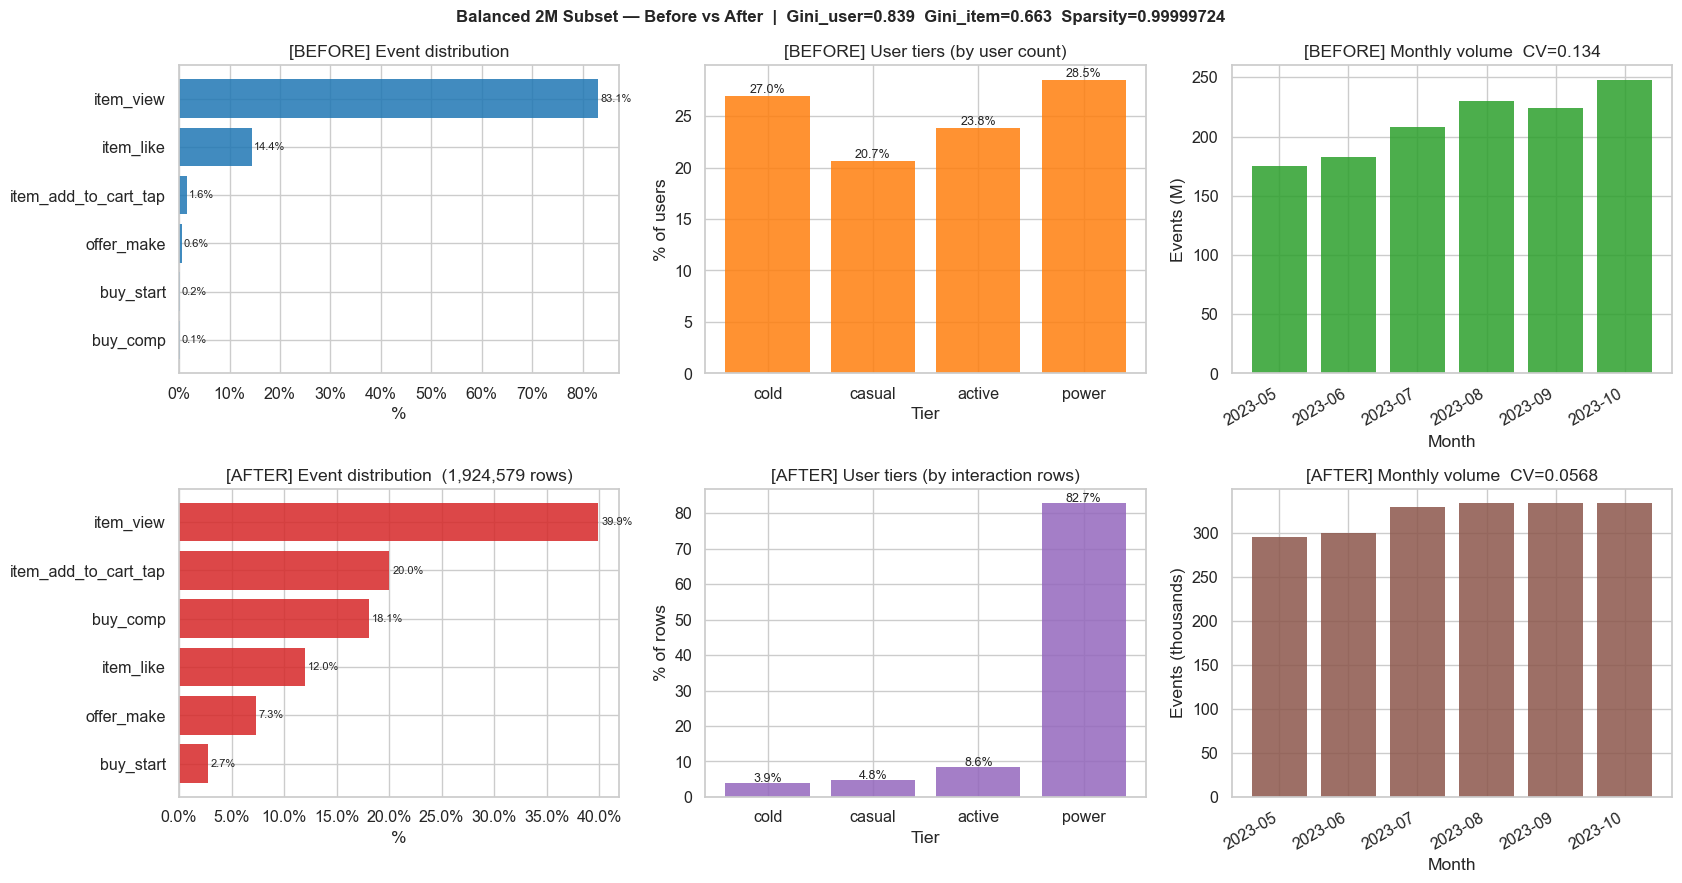

  ✓ saved before_after_dashboard.png


In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# Before / After Dashboard
# Requires: con, raw view, s3_monthly (from Stage 3), final view, user_tiers.
# ══════════════════════════════════════════════════════════════════════════════

con.execute("DROP VIEW IF EXISTS final")
con.execute(f"CREATE VIEW final AS SELECT * FROM read_parquet('{FINAL_PATH}')")

# ── Compute before distributions ───────────────────────────────────────────────
event_df = con.execute("""
    SELECT event_id, COUNT(*) AS cnt,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (), 2) AS pct
    FROM raw GROUP BY event_id ORDER BY cnt DESC
""").df()

monthly_df = con.execute("""
    SELECT DATE_TRUNC('month', stime)::DATE AS month, COUNT(*) AS cnt
    FROM raw GROUP BY month ORDER BY month
""").df()
monthly_df['month'] = pd.to_datetime(monthly_df['month'])
cv_monthly = monthly_df['cnt'].std() / monthly_df['cnt'].mean()

# ── Compute after distributions ────────────────────────────────────────────────
final_ev = con.execute("""
    SELECT event_id, COUNT(*) AS cnt,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (), 2) AS pct
    FROM final GROUP BY event_id ORDER BY cnt DESC
""").df()

final_tier = con.execute("""
    SELECT tier,
           COUNT(*) AS cnt,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (), 2) AS pct
    FROM final
    GROUP BY tier
    ORDER BY MIN(user_raw_events)
""").df()

TIER_ORDER = ['cold', 'casual', 'active', 'power']

# ── 2×3 dashboard ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# Row 0: BEFORE
ax = axes[0, 0]
top = event_df.head(8)
ax.barh(top['event_id'][::-1], top['pct'][::-1], color=PAL[0], edgecolor='none', alpha=0.85)
ax.set(xlabel='%', title='[BEFORE] Event distribution')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
for i, p in enumerate(top['pct'][::-1]):
    ax.text(p + 0.3, i, f'{p:.1f}%', va='center', fontsize=8)

ax = axes[0, 1]
raw_tier_pct = con.execute("""
    SELECT tier, ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (), 2) AS pct
    FROM user_tiers GROUP BY tier
""").df().set_index('tier').reindex(TIER_ORDER)['pct'].fillna(0)
ax.bar(TIER_ORDER, raw_tier_pct, color=PAL[1], edgecolor='none', alpha=0.85)
ax.set(xlabel='Tier', ylabel='% of users', title='[BEFORE] User tiers (by user count)')
for i, v in enumerate(raw_tier_pct):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

ax = axes[0, 2]
monthly_df['m'] = monthly_df['month'].dt.strftime('%Y-%m')
ax.bar(monthly_df['m'], monthly_df['cnt']/1e6, color=PAL[2], edgecolor='none', alpha=0.85)
ax.set(xlabel='Month', ylabel='Events (M)', title=f'[BEFORE] Monthly volume  CV={cv_monthly:.3f}')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Row 1: AFTER
ax = axes[1, 0]
ax.barh(final_ev['event_id'][::-1], final_ev['pct'][::-1], color=PAL[3], edgecolor='none', alpha=0.85)
ax.set(xlabel='%', title=f'[AFTER] Event distribution  ({final_ev["cnt"].sum():,} rows)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
for i, p in enumerate(final_ev['pct'][::-1]):
    ax.text(p + 0.3, i, f'{p:.1f}%', va='center', fontsize=8)

ax = axes[1, 1]
ft_pct = final_tier.set_index('tier').reindex(TIER_ORDER)['pct'].fillna(0)
ax.bar(TIER_ORDER, ft_pct, color=PAL[4], edgecolor='none', alpha=0.85)
ax.set(xlabel='Tier', ylabel='% of rows', title='[AFTER] User tiers (by interaction rows)')
for i, v in enumerate(ft_pct):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

ax = axes[1, 2]
s3_monthly['m'] = s3_monthly['month'].dt.strftime('%Y-%m')
cv_after_plot = s3_monthly['cnt'].std() / s3_monthly['cnt'].mean()
ax.bar(s3_monthly['m'], s3_monthly['cnt']/1e3, color=PAL[5], edgecolor='none', alpha=0.85)
ax.set(xlabel='Month', ylabel='Events (thousands)', title=f'[AFTER] Monthly volume  CV={cv_after_plot:.4f}')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

fig.suptitle(
    'Balanced 2M Subset — Before vs After  |  '
    'Gini_user=0.839  Gini_item=0.663  Sparsity=0.99999724',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'before_after_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('  ✓ saved before_after_dashboard.png')

---
## 8. Audit Report & Summary

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# Audit Report & Summary
# ══════════════════════════════════════════════════════════════════════════════

final_pos_rate = float(final_ev.loc[final_ev['event_id']=='item_view','pct'].iloc[0]) \
                 if 'item_view' in final_ev['event_id'].values else 0.0
iv_raw_pct     = AVAIL_MAP['item_view'] / total_avail * 100
cv_after_val   = float(s3_monthly['cnt'].std() / s3_monthly['cnt'].mean())

report = {
    'generated_at' : datetime.now().isoformat(),
    'output_path'  : str(FINAL_PATH),
    'config': {
        'target_rows'   : 2_000_000,
        'seed'          : 42,
        'event_weights' : EVENT_WEIGHTS,
        'tier_bounds'   : {k: list(v) for k, v in TIER_BOUNDS.items()},
        'n_months'      : 6,
    },
    'imbalance_correction': {
        'item_view_pct_before' : round(iv_raw_pct, 2),
        'item_view_pct_after'  : round(final_pos_rate, 2),
        'monthly_cv_before'    : round(float(cv_monthly), 4),
        'monthly_cv_after'     : round(cv_after_val, 4),
        'tier_rebalancing'     : 'skipped — power users dominate s1 (82.8%), cold/casual/active capped at 100%',
    },
    'results': {
        'total_rows'  : written,
        'file_size_mb': round(size_mb, 1),
        'sort_order'  : '(user_id, stime)',
        
    },
    'intermediate_files': {
        's1_events'  : str(S1_PATH),
        's2_tiers'   : str(S2_PATH),
        's3_temporal': str(S3_PATH),
        'user_tiers' : str(TIER_PATH),
    },
}

REPORT_PATH = OUT_DIR / 'merrec_balanced_2M_report.json'
with open(REPORT_PATH, 'w') as f:
    json.dump(report, f, indent=2)

con.close()

print('=' * 60)
print('  BALANCED 2M SUBSET — COMPLETE')
print('=' * 60)
print(f'  Output      : {FINAL_PATH}')
print(f'  Rows        : {written:,}')
print(f'  File size   : {size_mb:.0f} MB')

print()
print('  Imbalance corrections:')
print(f'    item_view rate : {iv_raw_pct:.1f}% → {final_pos_rate:.1f}%  (BCE label=1)')
print(f'    Monthly CV     : {cv_monthly:.3f} → {cv_after_val:.4f}')
print(f'    Sort order     : (user_id, stime) ✓')
print()
print('  To use in UMAG notebook (one line change):')
print('    DATASET_PATH = Path("/Volumes/T5 EVO/hf/merrec_balanced_2M")')
print('=' * 60)

  BALANCED 2M SUBSET — COMPLETE
  Output      : /Volumes/T5 EVO/hf/merrec_balanced_2M/merrec_balanced_2M.parquet
  Rows        : 1,924,579
  File size   : 107 MB

  Imbalance corrections:
    item_view rate : 83.1% → 39.9%  (BCE label=1)
    Monthly CV     : 0.134 → 0.0568
    Sort order     : (user_id, stime) ✓

  To use in UMAG notebook (one line change):
    DATASET_PATH = Path("/Volumes/T5 EVO/hf/merrec_balanced_2M")
